# 第035讲 动量与加速方法
同一四行回归：逐样本前向、两轮动量、状态谱、真实PyTorch约定。请从本单元目录启动并顺序执行。

In [1]:
from pathlib import Path
import hashlib, sys
ROOT = Path.cwd()
if not (ROOT/'experiment.py').is_file():
    raise ValueError('请从本单元目录启动')
BASELINE = {'data/regression.csv': '06678c8c19868fa6f4dad9fba345f31947cd05f224d38f77d00a98fdfe6199de', 'data/model_spec.json': '8cef37e4c97280dd15772b8fbf89834dd15e7c39b61c1b3bafafb7df742e6721'}
for name, expected in BASELINE.items():
    if hashlib.sha256((ROOT/name).read_bytes()).hexdigest() != expected:
        raise ValueError('完整默认输入已改变，固定说明不再适用：'+name)
sys.path.insert(0,str(ROOT))
import experiment as ex
data,spec=ex.load_inputs()
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction as F
from IPython.display import display, Image
import io
def show(fig):
    buf=io.BytesIO();fig.savefig(buf,format='png',dpi=140,bbox_inches='tight');display(Image(data=buf.getvalue()))
print('完整字节和字段验证通过。Python',sys.version.split()[0], 'NumPy', np.__version__)
print('rows',data)

完整字节和字段验证通过。Python 3.12.14 NumPy 2.3.5
rows [[1.0, 4.0, 1.0], [1.0, -4.0, 1.0], [-1.0, 4.0, -1.0], [-1.0, -4.0, -1.0]]


## 1 独立的逐样本Fraction前向
单行贡献r²/8，因此局部导数r/4。每个参数都累积四行。这里不调用生产前向函数。

In [2]:
fd=[[F(v) for v in row] for row in data]
def exact_forward(p):
    g=[F(0),F(0)];loss=F(0)
    for i,(x1,x2,y) in enumerate(fd):
        pred=x1*p[0]+x2*p[1];r=pred-y;part=r*r/8;c=[r*x1/4,r*x2/4]
        print('row',i+1,'prediction',pred,'residual',r,'r²/8',part,'local derivatives',r/4,1,[x1,x2],'contribution',list(map(str,c)))
        g=[g[j]+c[j] for j in range(2)];loss+=part
    print('F',loss,'accumulated gradient',list(map(str,g)))
    return g,loss
exact_forward([F(0),F(1)])

row 1 prediction 4 residual 3 r²/8 9/8 local derivatives 3/4 1 [Fraction(1, 1), Fraction(4, 1)] contribution ['3/4', '3']
row 2 prediction -4 residual -5 r²/8 25/8 local derivatives -5/4 1 [Fraction(1, 1), Fraction(-4, 1)] contribution ['-5/4', '5']
row 3 prediction 4 residual 5 r²/8 25/8 local derivatives 5/4 1 [Fraction(-1, 1), Fraction(4, 1)] contribution ['-5/4', '5']
row 4 prediction -4 residual -3 r²/8 9/8 local derivatives -3/4 1 [Fraction(-1, 1), Fraction(-4, 1)] contribution ['3/4', '3']
F 17/2 accumulated gradient ['-1', '16']


([Fraction(-1, 1), Fraction(16, 1)], Fraction(17, 2))

## 2 Heavy-ball两轮完整链
每一步都先旧点前向，再同步更新两个坐标，最后做下一轮前向。打印的损失包含相同平均因子。

In [3]:
hand_states={}
for method in ['hb','nag']:
    p=[F(0),F(1)];d=[F(0),F(0)];records=[]
    print('METHOD',method)
    for t in range(2):
        print('OLD',t,list(map(str,p)),'velocity',list(map(str,d)));exact_forward(p)
        point=[p[j]+d[j]/2 for j in range(2)] if method=='nag' else p[:]
        print('GRADIENT POINT',list(map(str,point)));g,loss=exact_forward(point)
        nd=[d[j]/2-g[j]/16 for j in range(2)];np_=[p[j]+nd[j] for j in range(2)]
        print('SIMULTANEOUS new velocity',list(map(str,nd)),'new parameter',list(map(str,np_)))
        print('NEW FORWARD');exact_forward(np_);records.append(list(map(str,np_)));p,d=np_,nd
    hand_states[method]=records
    expected=[v['new']['theta'] for v in ex.hand_chain(data,spec,method)]
    if records!=expected:raise RuntimeError('独立手算不一致')

METHOD hb
OLD 0 ['0', '1'] velocity ['0', '0']
row 1 prediction 4 residual 3 r²/8 9/8 local derivatives 3/4 1 [Fraction(1, 1), Fraction(4, 1)] contribution ['3/4', '3']
row 2 prediction -4 residual -5 r²/8 25/8 local derivatives -5/4 1 [Fraction(1, 1), Fraction(-4, 1)] contribution ['-5/4', '5']
row 3 prediction 4 residual 5 r²/8 25/8 local derivatives 5/4 1 [Fraction(-1, 1), Fraction(4, 1)] contribution ['-5/4', '5']
row 4 prediction -4 residual -3 r²/8 9/8 local derivatives -3/4 1 [Fraction(-1, 1), Fraction(-4, 1)] contribution ['3/4', '3']
F 17/2 accumulated gradient ['-1', '16']
GRADIENT POINT ['0', '1']
row 1 prediction 4 residual 3 r²/8 9/8 local derivatives 3/4 1 [Fraction(1, 1), Fraction(4, 1)] contribution ['3/4', '3']
row 2 prediction -4 residual -5 r²/8 25/8 local derivatives -5/4 1 [Fraction(1, 1), Fraction(-4, 1)] contribution ['-5/4', '5']
row 3 prediction 4 residual 5 r²/8 25/8 local derivatives 5/4 1 [Fraction(-1, 1), Fraction(4, 1)] contribution ['-5/4', '5']
row 4 pre

## 3 执行全部有限预算轨迹
每次训练更新用四行；诊断前向额外计数。先看目标首次达标，不把耗尽预算写成收敛。

In [4]:
report=ex.run_experiment(data,spec);methods=report['methods']
for name,m in methods.items():
    print(name,'updates',m['updates'],'status',m['status'],'first target',m['first_target_t'],'training sample gradients',m['training_sample_gradients'],'diagnostic forwards',m['diagnostic_full_forwards'])
print('HB second-step loss',methods['hb_hand']['states'][2]['loss'])

gd_safe updates 80 status budget_exhausted first target None training sample gradients 320 diagnostic forwards 81
gd_balanced updates 80 status budget_exhausted first target 64 training sample gradients 320 diagnostic forwards 81
hb_hand updates 80 status budget_exhausted first target 42 training sample gradients 320 diagnostic forwards 81
nag_hand updates 80 status budget_exhausted first target 47 training sample gradients 320 diagnostic forwards 81
hb_quadratic_tuned updates 80 status budget_exhausted first target 23 training sample gradients 320 diagnostic forwards 81
nag_strongconvex updates 80 status budget_exhausted first target 31 training sample gradients 320 diagnostic forwards 81
hb_stress updates 80 status budget_exhausted first target None training sample gradients 320 diagnostic forwards 81
nag_stress updates 80 status budget_exhausted first target None training sample gradients 320 diagnostic forwards 81
HB second-step loss 2.3592605590820312


## 4 同参数的超调
曲线由刚刚运行的状态重算。与第032讲相比，位置不足以描述系统，必须保留速度。

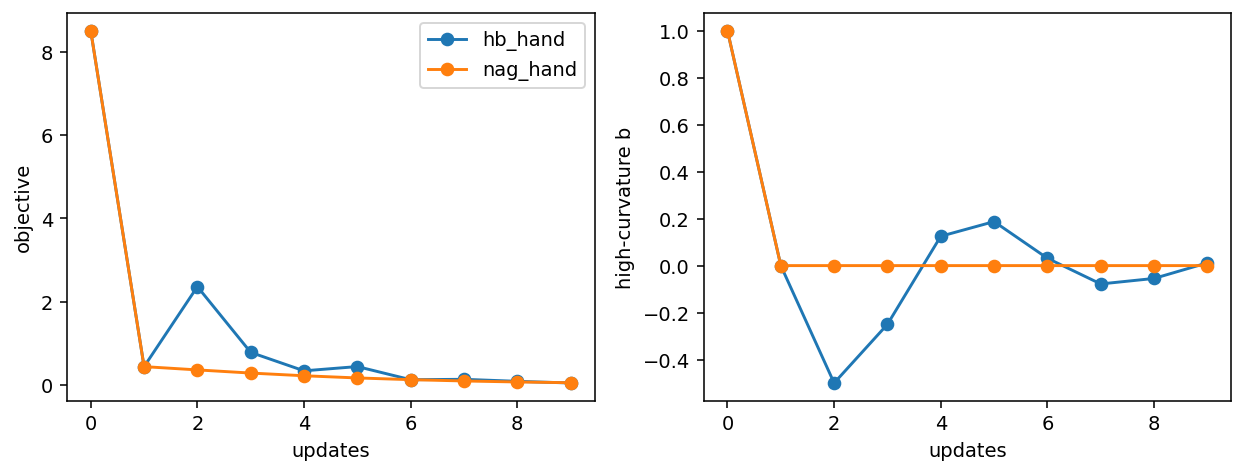

In [5]:
fig,axs=plt.subplots(1,2,figsize=(9,3.5))
for name in ['hb_hand','nag_hand']:
    st=methods[name]['states'][:10];axs[0].plot([v['t'] for v in st],[v['geometric_gap'] for v in st],'o-',label=name);axs[1].plot([v['t'] for v in st],[v['theta'][1] for v in st],'o-',label=name)
axs[0].set(xlabel='updates',ylabel='objective');axs[1].set(xlabel='updates',ylabel='high-curvature b');axs[0].legend();fig.tight_layout();show(fig);plt.close(fig)

## 5 二维状态矩阵和根
用NumPy eigvals独立核对二次多项式求根。每一个参数方向都有2维状态；两个参数合起来是4维。

In [6]:
for name in ['hb_hand','nag_hand','hb_quadratic_tuned','nag_strongconvex']:
    for sp in methods[name]['spectrum']:
        numerical=np.linalg.eigvals(np.array(sp['matrix'],float));rho=max(abs(numerical))
        if not np.isclose(rho,sp['spectral_radius'],rtol=2e-7,atol=1e-15):raise RuntimeError('state spectrum mismatch')
        print(name,'lambda',sp['lambda'],'A,D,delta',sp['A'],sp['D'],sp['discriminant'],'roots',sp['roots'],'rho',sp['spectral_radius'])
print('重根附近开方病态，eigvals允许2e-7相对差；这不是轨迹误差容差。')

hb_hand lambda 1 A,D,delta 1.4375 0.5 0.06640625 roots [[0.8475970508005519, 0.0], [0.5899029491994481, 0.0]] rho 0.8475970508005519
hb_hand lambda 16.0 A,D,delta 0.5 0.5 -1.75 roots [[0.25, 0.6614378277661477], [0.25, -0.6614378277661477]] rho 0.7071067811865476
nag_hand lambda 1 A,D,delta 1.40625 0.46875 0.1025390625 roots [[0.8632336057181187, 0.0], [0.5430163942818813, 0.0]] rho 0.8632336057181187
nag_hand lambda 16.0 A,D,delta 0.0 0.0 0.0 roots [[0.0, 0.0], [0.0, 0.0]] rho 0.0
hb_quadratic_tuned lambda 1 A,D,delta 1.2 0.36 0.0 roots [[0.6, 0.0], [0.6, 0.0]] rho 0.6
hb_quadratic_tuned lambda 16.0 A,D,delta -1.2000000000000002 0.36 4.440892098500626e-16 roots [[-0.5999999894632879, 0.0], [-0.6000000105367123, 0.0]] rho 0.6000000105367123
nag_strongconvex lambda 1 A,D,delta 1.5 0.5625 0.0 roots [[0.75, 0.0], [0.75, 0.0]] rho 0.75
nag_strongconvex lambda 16.0 A,D,delta 0.0 0.0 0.0 roots [[0.0, 0.0], [0.0, 0.0]] rho 0.0
重根附近开方病态，eigvals允许2e-7相对差；这不是轨迹误差容差。


## 6 稳定区域
正曲率、常数η和0≤β<1；边界排除。阴影来自解析Jury条件，非网格实验证明。

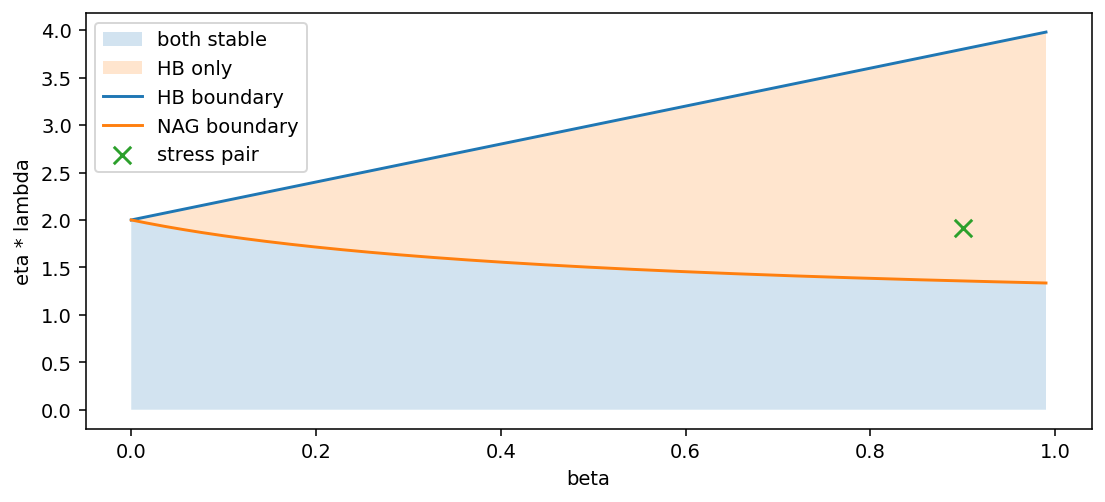

In [7]:
beta=np.linspace(0,.99,300);hb=2*(1+beta);nag=2*(1+beta)/(1+2*beta)
fig,ax=plt.subplots(figsize=(8,3.7));ax.fill_between(beta,0,nag,alpha=.2,label='both stable');ax.fill_between(beta,nag,hb,alpha=.2,label='HB only');ax.plot(beta,hb,label='HB boundary');ax.plot(beta,nag,label='NAG boundary');ax.scatter([.9],[1.92],marker='x',s=80,label='stress pair');ax.set(xlabel='beta',ylabel='eta * lambda');ax.legend();fig.tight_layout();show(fig);plt.close(fig)

## 7 狭长谷底的真实轨迹与同预算曲线
每种方法分别采用已说明的理论设置。所有点均来自相同数据的逐样本梯度计算。

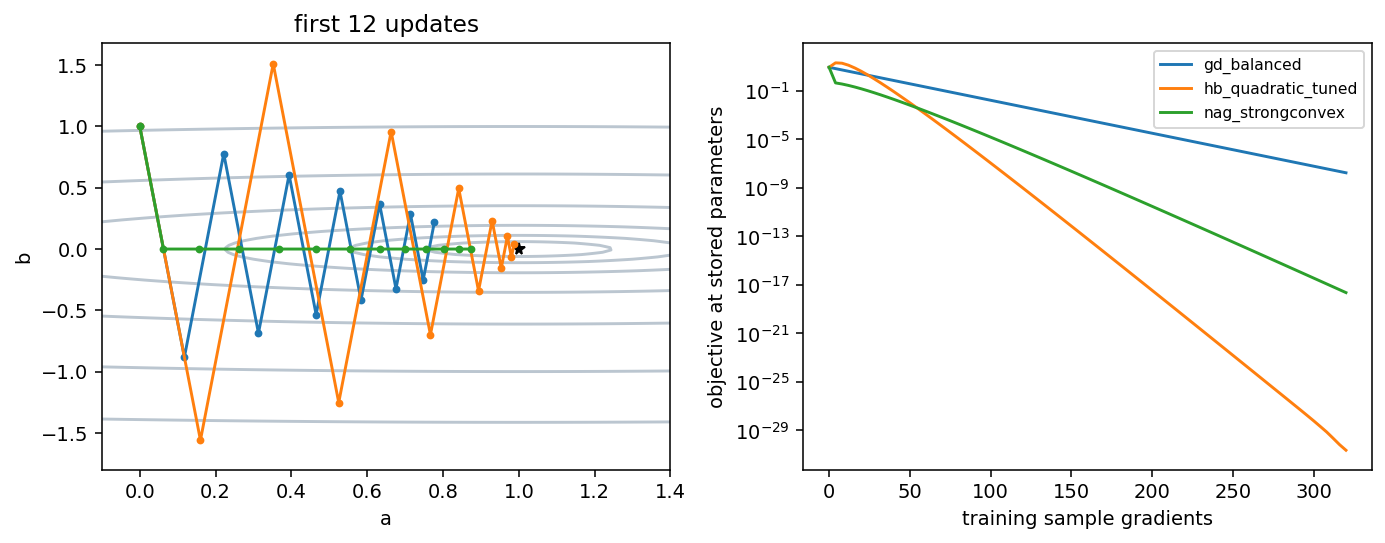

In [8]:
aa,bb=np.meshgrid(np.linspace(-.1,1.4,160),np.linspace(-1.8,1.2,160));zz=sum((x1*aa+x2*bb-y)**2 for x1,x2,y in data)/8
fig,axs=plt.subplots(1,2,figsize=(10,4));axs[0].contour(aa,bb,zz,levels=[.03,.1,.3,1,3,8,16],colors='#bbc6d0');axs[0].plot(1,0,'k*')
for name in ['gd_balanced','hb_quadratic_tuned','nag_strongconvex']:
    st=methods[name]['states'];p=np.array([v['theta'] for v in st[:13]]);axs[0].plot(p[:,0],p[:,1],'o-',ms=3,label=name);axs[1].semilogy([4*v['t'] for v in st],[v['geometric_gap'] for v in st],label=name)
axs[0].set(xlabel='a',ylabel='b',title='first 12 updates');axs[1].set(xlabel='training sample gradients',ylabel='objective at stored parameters');axs[1].legend(fontsize=8);fig.tight_layout();show(fig);plt.close(fig)

## 8 同一参数设置可以让HB稳定而NAG发散
此处ηL=1.92；NAG的上界约1.357。不是NAG“总是更差”，也不是稳定区域越宽就越快。

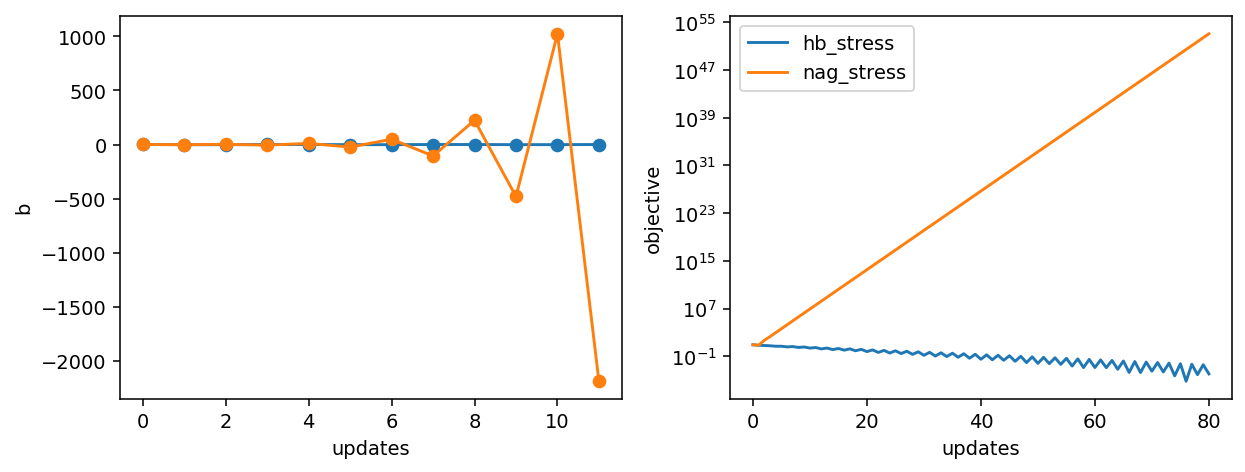

In [9]:
fig,axs=plt.subplots(1,2,figsize=(9,3.5))
for name in ['hb_stress','nag_stress']:
    st=methods[name]['states'];axs[0].plot([v['t'] for v in st[:12]],[v['theta'][1] for v in st[:12]],'o-',label=name);axs[1].semilogy([v['t'] for v in st],[v['geometric_gap'] for v in st],label=name)
axs[0].set(xlabel='updates',ylabel='b');axs[1].set(xlabel='updates',ylabel='objective');axs[1].legend();fig.tight_layout();show(fig);plt.close(fig)

## 9 真实PyTorch对照
在CPU float64单线程实际运行，关闭foreach/fused，dampening和weight_decay明确。NAG用重参数映射核对，不能直接比较原始parameter。

In [10]:
import library_check
library=library_check.run_checks(data,spec)
print('library status',library['status'],'torch',library['torch'],'max absolute error',library['max_absolute_comparison_error'])
for case in library['cases']:
    print(case['case'])
    for row in case['records'][:2]:
        print({k:v for k,v in row.items() if k in ['t','autograd_gradient','actual_gradient','torch_new_parameter','momentum_buffer','paper_theta_reconstructed','theta','buffer','rate','torch_theta','fixed_beta_displacement_theta','difference']})
print('nonzero dampening + Nesterov rejected',library['nesterov_nonzero_dampening_rejected'])

library status passed torch 2.7.1+cpu max absolute error 1.1102230246251565e-16
hb_constant
{'t': 0, 'autograd_gradient': [-1.0, 16.0], 'torch_new_parameter': [0.0625, 0.0], 'momentum_buffer': [-1.0, 16.0], 'paper_theta_reconstructed': [0.0625, 0.0]}
{'t': 1, 'autograd_gradient': [-0.9375, 0.0], 'torch_new_parameter': [0.15234375, -0.5], 'momentum_buffer': [-1.4375, 8.0], 'paper_theta_reconstructed': [0.15234375, -0.5]}
nag_constant
{'t': 0, 'autograd_gradient': [-1.0, 16.0], 'torch_new_parameter': [0.09375, -0.5], 'momentum_buffer': [-1.0, 16.0], 'paper_theta_reconstructed': [0.0625, 0.0]}
{'t': 1, 'autograd_gradient': [-0.90625, -8.0], 'torch_new_parameter': [0.1943359375, 0.0], 'momentum_buffer': [-1.40625, 0.0], 'paper_theta_reconstructed': [0.150390625, 0.0]}
dampening_first_buffer
{'t': 0, 'buffer': [-1.0, 16.0], 'theta': [0.0625, 0.0], 'actual_gradient': [-1.0, 16.0]}
{'t': 1, 'buffer': [-1.203125, 8.0], 'theta': [0.1376953125, -0.5], 'actual_gradient': [-0.9375, 0.0]}
scheduled

## 10 梯度缓冲区的坐标含义
左图的两个参数序列不应该相等；恢复paper θ后已通过上一格逐步比较。右图展示学习率变化时的真实差异。

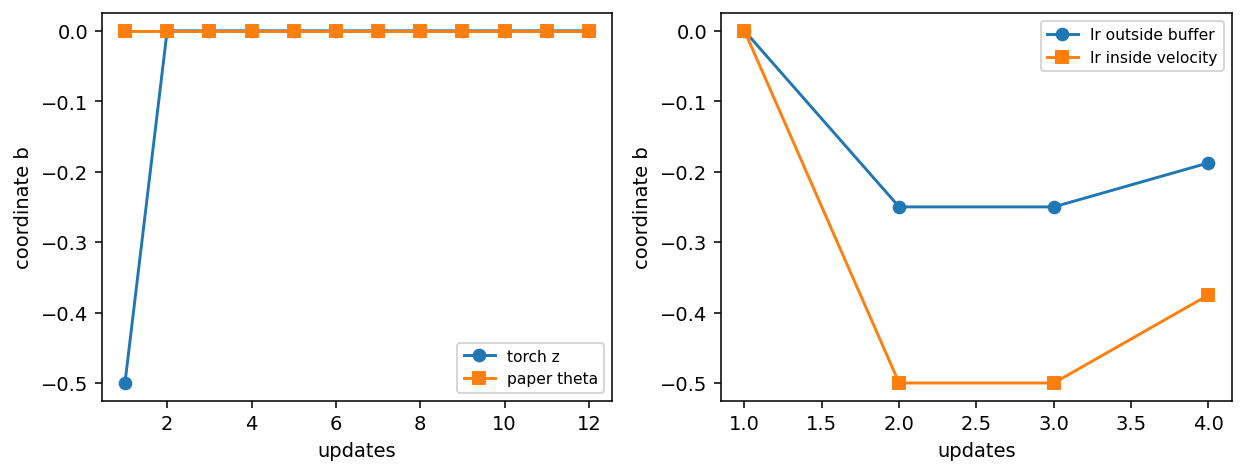

In [11]:
r=library['cases'][1]['records'];q=library['cases'][3]['records'];fig,axs=plt.subplots(1,2,figsize=(9,3.5))
axs[0].plot(range(1,len(r)+1),[x['torch_new_parameter'][1] for x in r],'o-',label='torch z');axs[0].plot(range(1,len(r)+1),[x['paper_theta_reconstructed'][1] for x in r],'s-',label='paper theta')
axs[1].plot(range(1,len(q)+1),[x['torch_theta'][1] for x in q],'o-',label='lr outside buffer');axs[1].plot(range(1,len(q)+1),[x['fixed_beta_displacement_theta'][1] for x in q],'s-',label='lr inside velocity')
for ax in axs:ax.set(xlabel='updates',ylabel='coordinate b');ax.legend(fontsize=8)
fig.tight_layout();show(fig);plt.close(fig)

## 11 浮点停滞与隐藏状态
参数一轮不动不能证明系统静止。报告既保留逐行前向损失，也保留在已存储坐标处稳定计算的几何目标。

same_point_with_velocity budget_exhausted 8
nearby_floating_stagnation floating_state_stagnation 2
parameter_pause_not_state_stop budget_exhausted 4
hb_boundary budget_exhausted 20
nag_boundary budget_exhausted 20


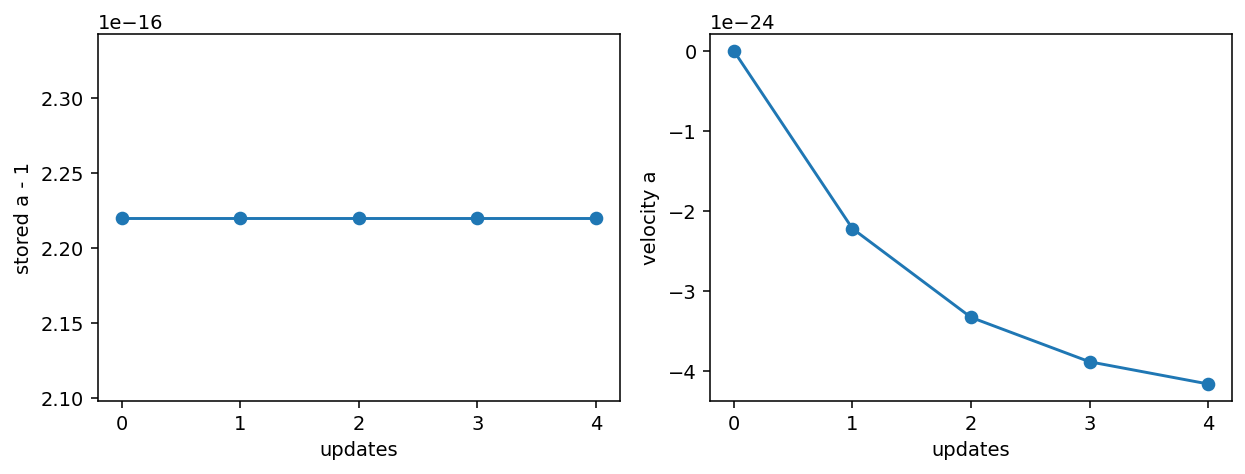

In [12]:
for name,p in report['probes'].items():print(name,p['status'],p['updates'])
p=report['probes']['parameter_pause_not_state_stop'];fig,axs=plt.subplots(1,2,figsize=(9,3.5));st=p['states'];axs[0].plot([r['t'] for r in st],[r['theta'][0]-1 for r in st],'o-');axs[1].plot([r['t'] for r in st],[r['velocity'][0] for r in st],'o-');axs[0].set(xlabel='updates',ylabel='stored a - 1');axs[1].set(xlabel='updates',ylabel='velocity a');fig.tight_layout();show(fig);plt.close(fig)
if not p['trace'][0]['parameter_unchanged'] or p['trace'][0]['whole_state_unchanged']:raise RuntimeError('pause distinction lost')

## 12 坏尾字段先失败
改内存副本，不改默认数据。哨兵保证没有进入任何更新。

In [13]:
import copy
bad=copy.deepcopy(spec);bad['schedule_rates'][-1]=True
old=ex._run;ex._run=lambda *a:(_ for _ in ()).throw(RuntimeError('不应开始计算'))
try:
    try:ex.run_experiment(data,bad)
    except ValueError as err:print('预期拒绝',err)
    else:raise RuntimeError('坏字段被接受')
finally:ex._run=old

预期拒绝 schedule_rates item: built-in int/float required, not bool


## 13 保存完整报告
本格只写results/，不覆盖输入。重新运行脚本可比较整份JSON的摘要。输出图不能替代源代码和假设审查。

In [14]:
payload=ex.report_bytes(report);target=ex.protect_output(ROOT/'results/notebook-report.json');ex.atomic_write(target,payload)
ex.atomic_write(ex.protect_output(ROOT/'results/notebook-library.json'),ex.report_bytes(library))
print('report SHA256',hashlib.sha256(payload).hexdigest())
print('完成有限机制实验；未据此推断非凸目标、随机梯度或真实硬件耗时的普遍加速。')

report SHA256 ae016ae31c0db91aca84911e4f68208428eb05c81664729d3e1eec81c9c37eb6
完成有限机制实验；未据此推断非凸目标、随机梯度或真实硬件耗时的普遍加速。
